In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from skimage import io
from sklearn.model_selection import train_test_split

from tqdm import tqdm

In [3]:
DATA_DIR = '/content/drive/MyDrive/SNN-TL-Data/train'
CSV_FILE = '/content/drive/MyDrive/SNN-TL-Data/train.csv'

In [4]:

BATCH_SIZE = 32
LR = 0.001
EPOCHS = 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [5]:
df = pd.read_csv(CSV_FILE)
df.head()

,Anchor,Negative,Positive
0,1420_c5s3_052165_01.jpg,1334_c6s3_061492_05.jpg,1420_c3s3_051678_01.jpg
1,1420_c3s3_061978_03.jpg,0234_c3s3_079494_02.jpg,1420_c6s3_085567_02.jpg
2,1420_c5s3_062565_05.jpg,0475_c2s1_122816_08.jpg,1420_c3s3_051653_01.jpg
3,1420_c6s3_085592_04.jpg,0662_c2s2_036662_05.jpg,1420_c1s6_013446_04.jpg
4,0663_c5s3_085987_03.jpg,1463_c2s3_098102_02.jpg,0663_c3s3_085544_06.jpg


In [6]:
row = df.iloc[1]

A_img = io.imread(DATA_DIR + '/' + row.Anchor)
P_img = io.imread(DATA_DIR + '/' + row.Positive)
N_img = io.imread(DATA_DIR + '/' + row. Negative)

In [7]:
class APN_Dataset(Dataset):

  def __init__(self, df):
    self.df = df

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):

    row = self.df.iloc[idx]

    A_img = io.imread(DATA_DIR + '/' + row.Anchor)
    P_img = io.imread(DATA_DIR + '/' + row.Positive)
    N_img = io.imread(DATA_DIR + '/' + row.Negative)

    A_img = torch.from_numpy(A_img).permute(2,0,1) / 255.0
    P_img = torch.from_numpy(P_img).permute(2,0,1) / 255.0
    N_img = torch.from_numpy(N_img).permute(2,0,1) / 255.0

    return A_img, P_img, N_img




In [8]:
train_df, valid_df = train_test_split(df, test_size = 0.20, random_state=42)

In [9]:
trainset = APN_Dataset (train_df)
validset = APN_Dataset (valid_df)

print(f"Size of trainset : {len(trainset)}")
print(f"Size of validset : {len(validset)}")

Size of trainset : 3200
Size of validset : 800


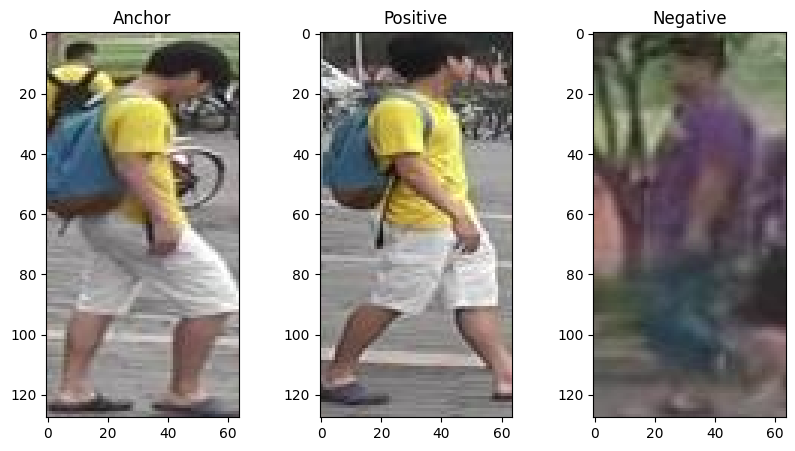

In [10]:
idx = 1
A,P,N = trainset[idx]

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10,5))

ax1.set_title('Anchor')
ax1.imshow(A.numpy().transpose((1,2,0)), cmap = 'gray')
ax2.set_title('Positive')
ax2.imshow(P.numpy().transpose((1,2,0)), cmap = 'gray')

ax3.set_title('Negative')
ax3.imshow(N.numpy().transpose((1,2,0)), cmap = 'gray')

In [11]:
trainloader = DataLoader(trainset, batch_size = BATCH_SIZE, shuffle = True)
validloader = DataLoader(validset, batch_size= BATCH_SIZE)

print(f"No. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

No. of batches in trainloader : 100
No. of batches in validloader : 25


In [12]:
class APN_Model(nn.Module):

  def __init__(self, emb_size = 512):

    super(APN_Model, self). __init__()

    self.efficientnet = timm.create_model('efficientnet_b0', pretrained = True)

    self.efficientnet.classifier = nn.Linear(in_features = self.efficientnet.classifier.in_features,out_features = emb_size)

  def forward(self, images):
    embeddings = self.efficientnet(images)

    return embeddings

In [13]:
model = APN_Model()

model.to(DEVICE);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [14]:
def train_fn(model, dataloader, optimizer, criterion):
  model.train()
  total_loss = 0.0
  for A, P, N in tqdm(dataloader):

    A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)
    A_embs = model(A)
    P_embs = model(P)
    N_embs = model(N)

    loss = criterion(A_embs, P_embs, N_embs)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

    return total_loss / len(dataloader)

In [15]:


def eval_fn(model, dataloader, criterion):
  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for A, P, N in tqdm(dataloader):

      A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)
      A_embs = model(A)
      P_embs = model(P)
      N_embs = model(N)

      loss = criterion(A_embs, P_embs, N_embs)
      total_loss += loss.item()

  return total_loss / len(dataloader)

In [16]:
criterion = nn.TripletMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LR)



In [17]:
best_valid_loss = np.inf
for i in range(EPOCHS):
  train_loss = train_fn(model, trainloader, optimizer, criterion)
  valid_loss = eval_fn(model, validloader, criterion)

if valid_loss < best_valid_loss:
  torch.save(model.state_dict(), 'best_model.pt')
  best_valid_loss = valid_loss
  print("Saved_Weights_Success")

print(
    f"Epochs: {i+1}"
    f"Train Loss: {train_loss}"
    f"Valid Loss: {valid_loss}"
)


100%|██████████| 25/25 [12:09<00:00, 29.17s/it]

Saved_Weights_Success
Epochs: 1Train Loss: 0.009523967504501343Valid Loss: 0.7881419682502746


In [18]:
#Getting anchor embeddings
def get_encoding_csv(model, anc_img_names):
    anc_img_names_arr = np.array(anc_img_names)
    encodings = []

    model.eval()

    with torch.no_grad():
        for i in tqdm(anc_img_names_arr):
            A = io.imread(DATA_DIR + '/' + i)
            A = torch.from_numpy(A).permute(2,0,1) / 255.0
            A = A.to(DEVICE)

            #(C, H, W) -> (1, C, H, W)
            A_enc = model(A.unsqueeze(0))


            encodings.append(
                A_enc.cpu().detach().numpy()
                )
    encodings = np.array(encodings)
    encodings = pd.DataFrame(encodings)

    df_enc = pd.concat([anc_img_names.reset_index(drop=True), encodings], axis = 1)

    return df_enc





In [19]:
def get_encoding_csv(model, anc_img_names):
    anc_img_names_arr = np.array(anc_img_names)
    encodings = []

    model.eval()

    with torch.no_grad():
        for i in tqdm(anc_img_names_arr):
            A = io.imread(DATA_DIR + '/' + i)
            A = torch.from_numpy(A).permute(2,0,1) / 255.0
            A = A.to(DEVICE)

            #(C, H, W) -> (1, C, H, W)
            A_enc = model(A.unsqueeze(0))


            encodings.append(
                A_enc.cpu().detach().numpy()
                )
    encodings = np.array(encodings)

    encodings = pd.DataFrame(encodings.squeeze(axis=1))

    df_enc = pd.concat([anc_img_names.reset_index(drop=True), encodings], axis = 1)

    return df_enc

model.load_state_dict(torch.load('best_model.pt'))
df_enc = get_encoding_csv(model, df['Anchor'])

df_enc.to_csv('database.csv', index=False)

df_enc.head()

100%|██████████| 4000/4000 [13:02<00:00,  5.11it/s]


,Anchor,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,1420_c5s3_052165_01.jpg,-0.236820,-0.088809,-0.109641,0.072543,0.347557,-0.014473,0.183698,0.002949,-0.204831,...,-0.137541,-0.121272,0.092867,-0.109840,-0.204776,0.044418,0.070838,0.008823,0.225517,0.338786
1,1420_c3s3_061978_03.jpg,-0.257396,0.070057,-0.051133,0.395587,0.325880,0.064026,0.245662,0.187221,-0.069788,...,0.048915,-0.080745,-0.101423,0.137192,0.111552,-0.321123,-0.250158,-0.331671,0.172543,0.359980
2,1420_c5s3_062565_05.jpg,-0.364043,0.349157,-0.060098,0.322982,0.157214,0.117155,0.203429,0.142891,-0.357314,...,0.188977,0.005771,-0.193889,0.366408,-0.150478,0.004436,-0.061838,-0.301769,0.061757,0.377412
3,1420_c6s3_085592_04.jpg,0.179976,-0.075816,0.104344,0.020588,0.045815,0.117494,0.108737,0.281268,-0.212341,...,0.188152,0.370924,-0.106912,0.244725,0.127637,-0.526711,-0.034802,0.064365,-0.120323,0.048861
4,0663_c5s3_085987_03.jpg,-0.382167,-0.095858,-0.081581,0.062307,0.355439,-0.122657,-0.053118,-0.042252,-0.047014,...,0.101685,0.000075,-0.270857,-0.088854,0.133169,-0.095978,-0.013346,-0.115391,0.339680,0.047739


In [20]:
def euclidean_dist(img_enc, anc_enc_arr):
  dist = np.sqrt(
      np.dot(img_enc - anc_enc_arr, (img_enc - anc_enc_arr).T)
  )
  return dist

In [21]:
idx = 0

img_name = df_enc['Anchor'].iloc[idx]
img_path = DATA_DIR + '/' + img_name

img = io.imread(img_path)
img = torch.from_numpy(img).permute(2, 0, 1) / 255.0

model.eval()
with torch.no_grad():
  img = img.to(DEVICE)
  img_enc = model(img.unsqueeze(0))
  img_enc = img_enc.cpu().detach().numpy()

In [22]:
anc_enc_arr = df_enc.iloc[:, 1:].to_numpy()
anc_img_names = df_enc['Anchor']


In [23]:
distance = []

for i in range(anc_enc_arr.shape[0]):
  dist = euclidean_dist(img_enc, anc_enc_arr[i:i+1, :])
  distance = np.append(distance, dist)

In [24]:
closest_idx = np.argsort(distance)

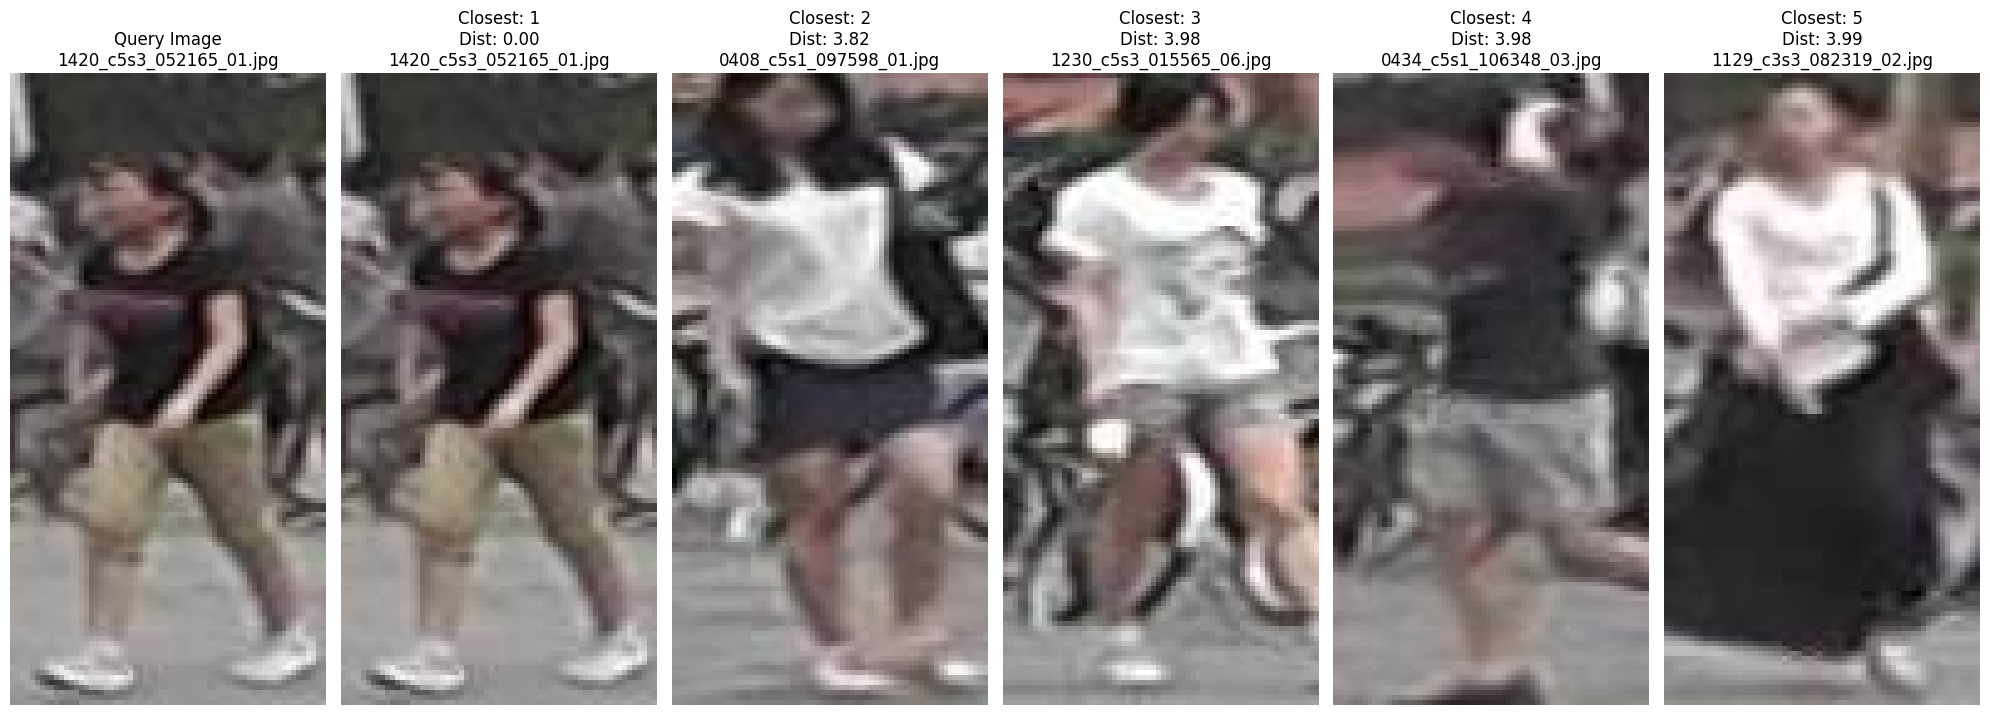

In [28]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

def plot_closest_imgs(anc_img_names, DATA_DIR, img, img_path, closest_idx, distance, no_of_closest=5):
    f, axarr = plt.subplots(1, no_of_closest + 1, figsize=(20, 20))

    axarr[0].imshow(img.cpu().numpy().transpose((1, 2, 0)), cmap='gray')
    axarr[0].set_title(f"Query Image\n{img_path.split('/')[-1]}")
    axarr[0].axis('off')

    for i in range(no_of_closest):
        idx = closest_idx[i]
        d = distance[idx]

        closest_img_name = anc_img_names.iloc[idx]
        closest_img_path = DATA_DIR + '/' + closest_img_name

        closest_img = io.imread(closest_img_path)
        axarr[i+1].imshow(closest_img)
        axarr[i+1].set_title(f"Closest: {i+1}\nDist: {d:.2f}\n{closest_img_name}")
        axarr[i+1].axis('off')
    plt.tight_layout()
    plt.show()

# The function definition for plot_closest_imgs is now directly in this cell.
# Therefore, we no longer need to import it from utils1.
# You can remove the 'from utils1 import plot_closest_imgs' line if you keep the function here.
# If you prefer to keep it in utils1.py, ensure the file is created at the correct path.
# For now, I'm making it self-contained for demonstration.
# If you save the above function to '/content/drive/MyDrive/SNN-TL-Data/utils1.py',
# then you would uncomment the following lines and remove the function definition above:
# sys.path.append('/content/drive/MyDrive/SNN-TL-Data')
# from utils1 import plot_closest_imgs

plot_closest_imgs(anc_img_names, DATA_DIR, img, img_path, closest_idx, distance, no_of_closest = 5)


In [29]:
TEST_DIR = "/content/drive/MyDrive/dataset"

In [30]:
def get_encoding_test(model, img_path):

    img = io.imread(img_path)
    img = torch.from_numpy(img).permute(2,0,1) / 255.0
    img = img.to(DEVICE)

    model.eval()
    with torch.no_grad():
        enc = model(img.unsqueeze(0))

    return enc.cpu().detach().numpy()

In [34]:
import os

test_img_paths = []
test_encodings = []

for person in os.listdir(TEST_DIR):

    person_path = os.path.join(TEST_DIR, person)

    if os.path.isdir(person_path):

        for img_name in os.listdir(person_path):

            img_path = os.path.join(person_path, img_name)

            test_img_paths.append(img_path)

            enc = get_encoding_test(model, img_path)
            test_encodings.append(enc)

test_encodings = np.vstack(test_encodings)

print("✅ Test dataset embeddings ready")

✅ Test dataset embeddings ready


In [60]:
import os

# List contents of the 'sakina' directory to find the correct filename
sakina_dir = os.path.join(TEST_DIR, "sakina")
if os.path.exists(sakina_dir):
    print(f"Contents of {sakina_dir}:")
    for item in os.listdir(sakina_dir):
        print(item)
else:
    print(f"Directory not found: {sakina_dir}")

# Original code (now corrected to use an existing filename)
query_img = TEST_DIR + "/reshma/reshma_1.jpg"
query_enc = get_encoding_test(model, query_img)

Contents of /content/drive/MyDrive/dataset/sakina:
sakina_4.jpg
sakina_1.jpg
sakina_2.jpg
sakina_3.jpg


In [61]:
distance = []

for i in range(test_encodings.shape[0]):
    dist = euclidean_dist(query_enc, test_encodings[i:i+1, :])
    distance = np.append(distance, dist)

closest_idx = np.argsort(distance)


In [62]:
for i in range(5):
    print(test_img_paths[closest_idx[i]], " -> Distance:", distance[closest_idx[i]])


/content/drive/MyDrive/dataset/reshma/reshma_1.jpg  -> Distance: 0.0
/content/drive/MyDrive/dataset/reshma/reshma_4.jpg  -> Distance: 0.9028000831604004
/content/drive/MyDrive/dataset/reshma/reshma_3.jpg  -> Distance: 1.0615289211273193
/content/drive/MyDrive/dataset/reshma/reshma_2.jpg  -> Distance: 1.0887274742126465
/content/drive/MyDrive/dataset/ishita/ishita_2.jpg  -> Distance: 2.3845314979553223


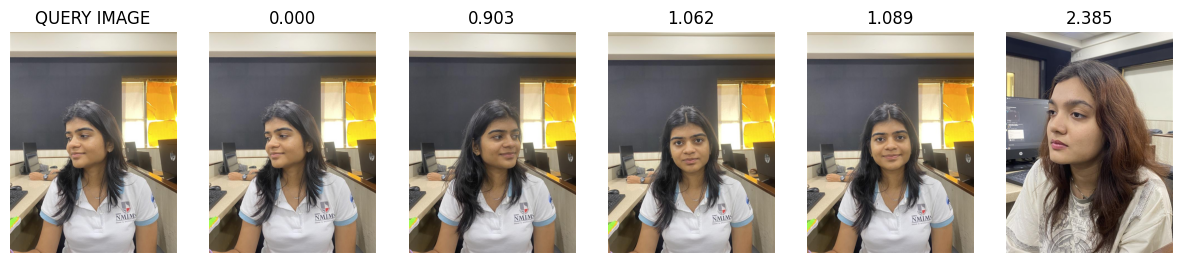

In [63]:
import matplotlib.pyplot as plt

# show query image first
plt.figure(figsize=(15,3))

plt.subplot(1,6,1)
query_display = io.imread(query_img)
plt.imshow(query_display)
plt.title("QUERY IMAGE")
plt.axis("off")

# show closest 5 matches
for i in range(5):

    img_path = test_img_paths[closest_idx[i]]
    img = io.imread(img_path)

    plt.subplot(1,6,i+2)
    plt.imshow(img)
    plt.title(f"{distance[closest_idx[i]]:.3f}")
    plt.axis("off")

plt.show()
